# Kernel Methods
*University of Ljubljana, Faculty of Computer and Information Science* <br />
*Course: Machine Learning, 2024-2025*

Teodora Taleska

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.kernel_ridge import KernelRidge

### Data Preprocessing

In [84]:
data = pd.read_csv('../data/breast_cancer_data.csv')

In [85]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [86]:
null_values = data.isnull().sum()
print(null_values[null_values > 0])

Series([], dtype: int64)


In [87]:
# Encode the 'diagnosis' column (Malignant - M -> 1, Benign - B -> 0)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [88]:
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Use the Scikit-learn implementation
Use the Scikit-learn implementation of SVM (the SVC() function)  to predict if the tumor is malignant or not. 
Try different:
- kernels
- regularization parameters
- different σ values when using the RBF kernel (in Scikit-learn this is the γ parameter).

Find the best values for the parameters and do a grid search. Tip: take a look at the GridSearchCV() function.

In [89]:
svm_params = {
    'C': [0.1, 1, 10], 
    'kernel': ['linear', 'poly', 'rbf'], 
    'gamma': ['scale', 'auto'],  # gamma values for RBF kernel
}

svm = SVC()
grid_search = GridSearchCV(svm, svm_params, cv=5)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters for SVM: {grid_search.best_params_}")
best_svm = grid_search.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm)}")

Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

SVM Accuracy: 0.9736842105263158


### Implementation of Kernel Ridge Regression 
1. Implement kernel ridge regression to model the data from Učilnica.
2. Implementation of different kernels. Which is the most suitable model?

In [125]:
data = pd.read_csv('../data/data.csv')

In [126]:
data.describe()

,x,y
count,197.000000,197.000000
mean,25.500000,62.334569
std,14.253289,37.981865
min,1.000000,9.431360
25%,13.250000,29.512333
50%,25.500000,53.280114
75%,37.750000,94.376284
max,50.000000,150.564864


In [127]:
null_values = data.isnull().sum()
null_values

x    0
y    0
dtype: int64

In [128]:
X = data[['x']].values  
y = data['y'].values

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split training data into train2 and validation data for hyperparameter tuning
X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  

In [130]:
# scaling the data is necessary for kernel ridge regression and most SVM kernels
scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [131]:
# Test different kernels for Kernel Ridge Regression from scikit learn
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    print(f"\nTraining Kernel Ridge Regression with {kernel} kernel...")
    
    best_model = None
    best_score = float('inf')
    best_params = None
    
    alphas = [0.01, 0.1, 1, 10]
    gammas = [0.01, 0.1, 1, 10] if kernel != 'linear' else [None]
    
    for alpha in alphas:
        for gamma in gammas:
            params = {'alpha': alpha, 'kernel': kernel}
            if gamma is not None:
                params['gamma'] = gamma
            
            model = KernelRidge(**params)
            model.fit(X_train2_scaled, y_train2)
            
            # Validate on validation set
            y_val_pred = model.predict(X_val_scaled)
            val_mse = mean_squared_error(y_val, y_val_pred)
            
            if val_mse < best_score:
                best_score = val_mse
                best_model = model
                best_params = params
    
    results[kernel] = {'model': best_model, 'params': best_params, 'val_mse': best_score}

    # Test on test set
    y_test_pred = best_model.predict(X_test_scaled)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"Best Params for {kernel}: {best_params}")
    print(f"Validation MSE: {best_score:.4f}, Test MSE: {test_mse:.4f}")


Training Kernel Ridge Regression with linear kernel...
Best Params for linear: {'alpha': 0.01, 'kernel': 'linear'}
Validation MSE: 3570.1309, Test MSE: 3499.9343

Training Kernel Ridge Regression with poly kernel...
Best Params for poly: {'alpha': 1, 'kernel': 'poly', 'gamma': 1}
Validation MSE: 37.8974, Test MSE: 39.7931

Training Kernel Ridge Regression with rbf kernel...
Best Params for rbf: {'alpha': 0.01, 'kernel': 'rbf', 'gamma': 10}
Validation MSE: 9.3842, Test MSE: 6.8562

Training Kernel Ridge Regression with sigmoid kernel...
Best Params for sigmoid: {'alpha': 0.01, 'kernel': 'sigmoid', 'gamma': 0.1}
Validation MSE: 39.2977, Test MSE: 39.0543


C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


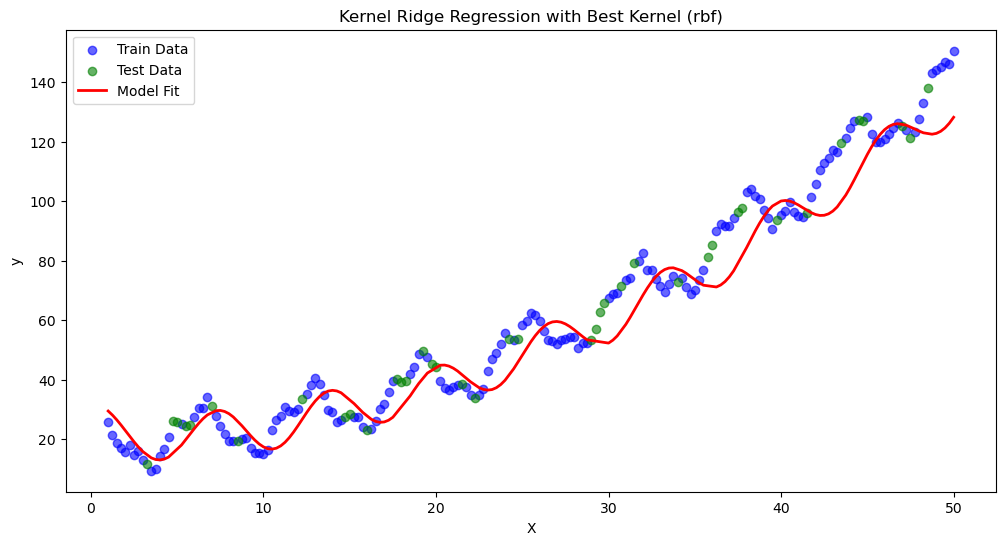

In [132]:
# Plotting the best model fit
best_kernel = min(results, key=lambda k: results[k]['val_mse'])
best_model = results[best_kernel]['model']

X_train_scaled = scaler.fit_transform(X_train)
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='blue', label='Train Data', alpha=0.6)
plt.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.6)
plt.plot(np.sort(X_train, axis=0), 
         best_model.predict(np.sort(X_train_scaled, axis=0)), 
         color='red', label='Model Fit', linewidth=2)
plt.title(f"Kernel Ridge Regression with Best Kernel ({best_kernel})")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### Kernel Ridge Regression from scratch

In [133]:
# kernel functions
def linear_kernel(X1, X2):
    return np.dot(X1, X2.T)

def polynomial_kernel(X1, X2, degree=3, coef0=1):
    return (np.dot(X1, X2.T) + coef0) ** degree

def rbf_kernel(X1, X2, gamma=1.0):
    pairwise_sq_dists = np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * pairwise_sq_dists)

def sigmoid_kernel(X1, X2, gamma=1.0, coef0=1.0):
    return np.tanh(gamma * np.dot(X1, X2.T) + coef0)

In [134]:
class KernelRidgeRegression:
    def __init__(self, kernel='linear', alpha=1.0, **kwargs):
        self.kernel = kernel
        self.alpha = alpha
        self.kernel_params = kwargs
        self.X_train = None
        self.alpha_weights = None

    def compute_kernel(self, X1, X2):
        if self.kernel == 'linear':
            return linear_kernel(X1, X2)
        elif self.kernel == 'poly':
            return polynomial_kernel(X1, X2, **self.kernel_params)
        elif self.kernel == 'rbf':
            return rbf_kernel(X1, X2, **self.kernel_params)
        elif self.kernel == 'sigmoid':
            return sigmoid_kernel(X1, X2, **self.kernel_params)
        else:
            raise ValueError(f"Unsupported kernel: {self.kernel}")

    def fit(self, X, y):
        self.X_train = X
        K = self.compute_kernel(X, X)  # Compute kernel matrix
        n = K.shape[0]
        self.alpha_weights = np.linalg.solve(K + self.alpha * np.eye(n), y)  # Solve the ridge regression dual problem

    def predict(self, X):
        K_test = self.compute_kernel(X, self.X_train)  # Compute kernel matrix for test data
        return np.dot(K_test, self.alpha_weights)

In [135]:
# Test different kernels for Kernel Ridge Regression
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    print(f"\nTraining Kernel Ridge Regression with {kernel} kernel...")
    
    best_model = None
    best_score = float('inf')
    best_params = None
    
    alphas = [0.01, 0.1, 1, 10, 100]
    gammas = [0.001, 0.01, 0.1, 1, 10] if kernel != 'linear' else [None] 
    degrees = [3] if kernel == 'poly' else [None] 

    for alpha in alphas:
        for gamma in gammas:
            for degree in degrees:
                params = {'alpha': alpha, 'kernel': kernel}
                if gamma is not None:
                    params['gamma'] = gamma
                if degree is not None:
                    params['degree'] = degree
                
                try:
                    model = KernelRidge(**params)
                    model.fit(X_train2_scaled, y_train2)

                    # Validate on validation set
                    y_val_pred = model.predict(X_val_scaled)
                    val_mse = mean_squared_error(y_val, y_val_pred)

                    if val_mse < best_score:
                        best_score = val_mse
                        best_model = model
                        best_params = params

                except np.linalg.LinAlgError as e:
                    print(f"Numerical issue with params {params}: {e}")
    
    results[kernel] = {'model': best_model, 'params': best_params, 'val_mse': best_score}

    # Test on test set
    y_test_pred = best_model.predict(X_test_scaled)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"Best Params for {kernel}: {best_params}")
    print(f"Validation MSE: {best_score:.4f}, Test MSE: {test_mse:.4f}")



Training Kernel Ridge Regression with linear kernel...
Best Params for linear: {'alpha': 0.01, 'kernel': 'linear'}
Validation MSE: 3570.1309, Test MSE: 3499.9343

Training Kernel Ridge Regression with poly kernel...
Best Params for poly: {'alpha': 1, 'kernel': 'poly', 'gamma': 1, 'degree': 3}
Validation MSE: 37.8974, Test MSE: 39.7931

Training Kernel Ridge Regression with rbf kernel...
Best Params for rbf: {'alpha': 0.01, 'kernel': 'rbf', 'gamma': 10}
Validation MSE: 9.3842, Test MSE: 6.8562

Training Kernel Ridge Regression with sigmoid kernel...
Best Params for sigmoid: {'alpha': 0.01, 'kernel': 'sigmoid', 'gamma': 0.1}
Validation MSE: 39.2977, Test MSE: 39.0543


C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
C:\Users\Teodora\miniconda3\envs\ids\lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


### Plot the model fit to your train data and to the predictions
Ridge regression is a linear model. What kind of predictions did you get? Comment.

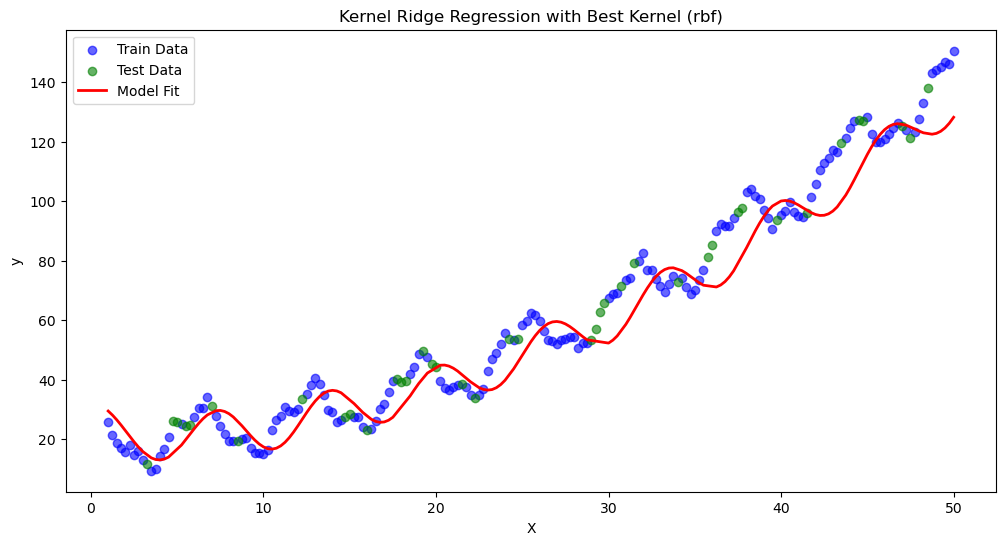

In [137]:
best_kernel = min(results, key=lambda k: results[k]['val_mse'])
best_model = results[best_kernel]['model']

X_train_scaled = scaler.fit_transform(X_train)
y_test_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='blue', label='Train Data', alpha=0.6)
plt.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.6)
plt.plot(np.sort(X_train, axis=0), 
         best_model.predict(np.sort(X_train_scaled, axis=0)), 
         color='red', label='Model Fit', linewidth=2)
plt.title(f"Kernel Ridge Regression with Best Kernel ({best_kernel})")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### Conclusion
The results highlight the importance of selecting an appropriate kernel for Kernel Ridge Regression when modeling complex, nonlinear data. Among the tested kernels, the RBF kernel demonstrated the best performance, achieving the lowest test MSE (6.86) due to its ability to effectively capture intricate, nonlinear patterns in the data. In contrast, the linear kernel performed poorly (test MSE: 3499.93), indicating that the dataset's relationships are far from linear. The polynomial and sigmoid kernels provided moderate improvements, but their performance was still inferior to the RBF kernel, suggesting they could not fully capture the data's complexity. Overall, the RBF kernel is the most suitable choice for this task, providing the best model fit and predictive accuracy.